In [1]:
import os, re
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
from scipy.stats import zscore
import pingouin as pg
import seaborn as sns
from scipy.stats import pearsonr
import pickle
import itertools

import torch
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
from sentence_transformers import SentenceTransformer
from transformers import GPT2Tokenizer, GPT2LMHeadModel
base_path = 'C:/Users\hchen\Dropbox\PycharmProjects/false_mem'
def check_correct(t, c):
    return np.nan if np.isnan(t) else (t == 1 and c == 0)
# Vectorize the function to apply it element-wise
vectorize_correct = np.vectorize(check_correct,otypes=[object])

def check_false(t, c):
    return np.nan if np.isnan(t) else (t == 0 or c == 1)
# Vectorize the function to apply it element-wise
vectorize_false = np.vectorize(check_false,otypes=[object])

C:\Users\hchen\AppData\Roaming\Python\Python39\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.4.0, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
C:\Users\hchen\AppData\Roaming\Python\Python39\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


# Correlating age with false memory (confab or conflicts)


In [2]:
demo_path = 'C:/Users/hchen/Dropbox/PycharmProjects/speech2text_topic/data/integrated/demographic_oregontrail_baseball.xlsx'
demo_df = pd.read_excel(demo_path)
story_ids = ['oregontrail','baseball']
subfolders = ['prompt5','prompt1']
axis = 0  # 0=event, 1=subject
arr_perc_false = []
arr_perc_correct = []
arr_perc_conflict = []
arr_perc_overlap = []
arr_perc_confab = []
df_all = pd.DataFrame(columns=['story_id', 'par_id', 'age', 'event_id', 'centrality', 'PPL', 'PPL_context',
                                 'recall', 'conflict', 'confab', 'correct','false'])
keep_ids = np.load(base_path+'/features/keep_ids.npy',allow_pickle=True)[2:]
n=0
for j, (story_id, subfolder) in enumerate(zip(story_ids, subfolders)):
    recall_path = base_path+'/GPT_output/GPT_rating/%s_%s' % (story_id, subfolder)
    recall_paths = [recall_path + '/'+x
                    for x in os.listdir(recall_path) if 'prompt' not in x]
    story_segs = pd.read_excel('C:/Users/hchen\Dropbox\school_projects/2023/firebase_experiments\causality_rating\materials/story_segs.xlsx',
                               sheet_name='%s_segs' % story_id)['events'].to_list()
    story_segs = np.array(story_segs)[keep_ids[j]]

    centrality = np.load(base_path+'/features/centrality_%s.npy' % story_id)
    
    PPL = np.load(base_path+'/features/PPL_%s.npy' % story_id)
    PPL_context = np.load(base_path+'/features/PPL_context_%s.npy' % story_id)
    match_path = 'C:/Users/hchen/Dropbox/PycharmProjects/false_mem/GPT_output/GPT_matching/%s' % story_id
    id_path = 'C:/Users/hchen\Dropbox\PycharmProjects\speech2text_topic\data\integrated/all_first_two.xlsx'
    id_sheet = pd.read_excel(id_path)
    SAVE_PATH = base_path+'/GPT_output/GPT_summary'
    confab = np.load(SAVE_PATH+'/confab_%s_%s.npy'%(story_id,subfolder))[:,keep_ids[j]]
    true = np.load(SAVE_PATH+'/conflict_%s_%s.npy'%(story_id,subfolder))[:,keep_ids[j]]

    percent_recall = []
    for i in range(len(story_segs)):
        percent_recall.append((len(recall_paths)-np.sum(np.logical_or(np.isnan(confab[:,i]),np.isnan(true[:,i]))))/len(recall_paths))

    correct = vectorize_correct(true, confab).astype(float)
    false = vectorize_false(true,confab).astype(float)
    num_correct = np.nansum(correct,axis=axis)
    perc_correct = np.nansum(correct, axis=axis)/(np.array(percent_recall)*len(recall_paths))
    num_conflict = np.nansum(true==0, axis=axis)
    perc_conflict = np.nansum(true==0, axis=axis)/(np.array(percent_recall)*len(recall_paths))
    num_confab = np.nansum(confab==1, axis=axis)
    perc_confab = np.nansum(confab==1, axis=axis)/(np.array(percent_recall)*len(recall_paths))
    num_false = np.nansum(false, axis=axis)
    perc_false = num_false/(np.array(percent_recall)*len(recall_paths))
    perc_overlap = perc_confab+perc_conflict-perc_false
    #
    arr_perc_false.append(perc_false)
    arr_perc_correct.append(perc_correct)
    arr_perc_conflict.append(perc_conflict)
    arr_perc_overlap.append(perc_overlap)
    arr_perc_confab.append(perc_confab)

    for i in range(confab.shape[0]):  # person
        for k in range(confab.shape[1]):  # event
            if np.isnan(confab[i,k]):
                recall = 0
            else:
                recall = 1
            par_id = os.path.basename(recall_paths[i]).split('_')[0]
            age = demo_df.loc[demo_df['ID']==par_id,'Age'].values[0]
            platform = demo_df.loc[demo_df['ID']==par_id,'platform'].values[0]
            if platform == 'prolific':
                df_all.loc[n] = [story_id, par_id, age, keep_ids[j][k], centrality[k], PPL[k], PPL_context[k], 
                                 recall, true[i,k], confab[i,k], correct[i,k],false[i,k]]
                n+=1

perc_false = np.concatenate(arr_perc_false)
perc_correct = np.concatenate(arr_perc_correct)
perc_conflict = np.concatenate(arr_perc_conflict)
perc_overlap = np.concatenate(arr_perc_overlap)
perc_confab = np.concatenate(arr_perc_confab)
perc_recall = perc_false+perc_correct

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users\\hchen\\Dropbox\\PycharmProjects/false_mem/features/keep_ids.npy'

In [9]:
df_all.to_excel(base_path+'/correlation_sheets/centrality_age.xlsx')

### preliminary analysis (LMM analysis in R)

In [10]:
def agg_subject(sub_df):
    false_rate = np.sum(sub_df.false)/np.sum(sub_df.recall)
    true_rate = np.sum(sub_df.correct)/np.sum(sub_df.recall)
    conflict_rate = np.sum(sub_df.conflict)/np.sum(sub_df.recall)
    confab_rate = np.sum(sub_df.confab)/np.sum(sub_df.recall)
    recall_rate = np.sum(sub_df.recall)/len(sub_df)
    age = sub_df.age.values[0]
    return pd.Series(data=dict(false_rate=false_rate,true_rate=true_rate,
                                  conflict_rate=conflict_rate,confab_rate=confab_rate,
                                  recall_rate=recall_rate,age=age))
df_all = pd.read_excel(base_path+'/correlation_sheets/centrality_age.xlsx')
df_age = df_all.groupby('par_id').apply(agg_subject)

false_rate (-0.03927796134576925, 0.7618152518386205)


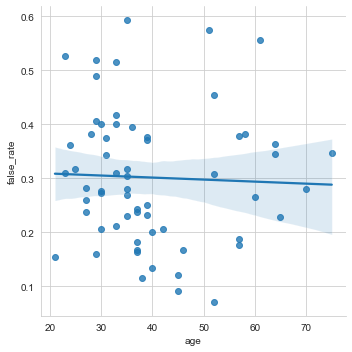

true_rate (0.03927796134576923, 0.7618152518386205)


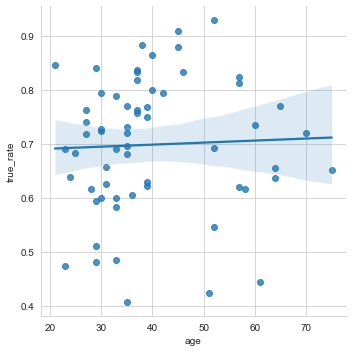

conflict_rate (0.08493896417507825, 0.5115752284766454)


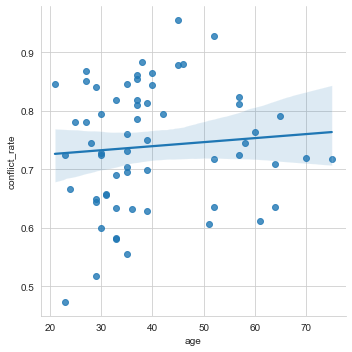

confab_rate (-0.0951281044524918, 0.46205571920903993)


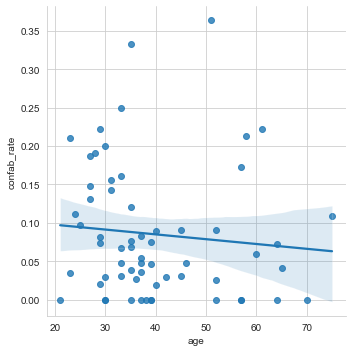

In [11]:
for y in ['false_rate','true_rate','conflict_rate','confab_rate']:
    print(y, pearsonr(df_age['age'],df_age[y]))
    sns.lmplot(x='age',y=y,data=df_age)
    plt.show()

## create datasheet for LLM with all stories (no age)

In [26]:
def find_index_for_sum(nums, target_sum):
    current_sum = 0
    for index, num in enumerate(nums):
        current_sum += num
        if current_sum == target_sum:
            return index
    return -1  # Return -1 if the target sum is not reached

story_ids = ['pieman','eyespy','oregontrail','baseball']
subfolders = ['prompt8','prompt5b','prompt5','prompt1']
model_ids = ['USE', 'USE','OPT' ] # prior knowledge, centrality, surprisal
axis = 0  # 0=event, 1=subject
arr_perc_false = []
arr_perc_correct = []
arr_perc_conflict = []
arr_perc_overlap = []
arr_perc_confab = []
arr_perc_inference = []
df_all = pd.DataFrame(columns=['story_id', 'par_id', 'event_id', 'centrality', 'PPL_context', 'entropy', 'prior',
                                 'recall', 'conflict', 'confab', 'correct','false','inference','length'])
keep_ids = np.load(base_path+'/E. semantic_features/keep_ids.npy',allow_pickle=True)
with open(base_path+'/E. semantic_features/PriorKnowledge_allstories_%s.pkl' % model_ids[0], 'rb') as file:
    pickled_prior=pickle.load(file)
n=0
for j, (story_id, subfolder) in enumerate(zip(story_ids, subfolders)):
    recall_path = base_path+'/GPT_output/GPT_rating/%s_%s' % (story_id, subfolder)
    recall_paths = [recall_path + '/'+x
                    for x in os.listdir(recall_path) if 'prompt' not in x]
    story_segs = pd.read_excel('C:/Users/hchen\Dropbox\school_projects/2023/firebase_experiments\causality_rating\materials/story_segs.xlsx',
                               sheet_name='%s_segs' % story_id)['events'].to_list()
    story_segs = np.array(story_segs)[keep_ids[j]]
    # features of the sentences
    centrality = np.load(base_path+'/E. semantic_features/centrality_%s_%s.npy' % (model_ids[1],story_id))
    prior = pickled_prior[j]
    PPL_context = np.load(base_path+'/E. semantic_features/PPL_context_%s_%s.npy' % (model_ids[2],story_id))
    entropy_context = np.load(base_path+'/E. semantic_features/renyi_entropy_%s.npy' % story_id)
    # performance
    match_path = 'C:/Users/hchen/Dropbox/PycharmProjects/false_mem/GPT_output/GPT_matching/%s' % story_id
    SAVE_PATH = base_path+'/GPT_output/GPT_summary'
    confab = np.load(SAVE_PATH+'/confab_%s_%s.npy'%(story_id,subfolder))[:, keep_ids[j]]
    true = np.load(SAVE_PATH+'/conflict_%s_%s.npy'%(story_id,subfolder))[:, keep_ids[j]]
    inference = np.load(SAVE_PATH+'/inference_%s_%s.npy'%(story_id,subfolder))[:, keep_ids[j]]
    correct = vectorize_correct(true, confab).astype(float)
    false = vectorize_false(true,confab).astype(float)
    # add data
    for i in range(confab.shape[0]):  # person
        for k in range(confab.shape[1]):  # event
            if np.isnan(confab[i,k]):
                recall = 0
            else:
                recall = 1
            par_id = os.path.basename(recall_paths[i]).split('_')[0]
            event_id = find_index_for_sum(keep_ids[j], k+1)
            df_all.loc[n] = [story_id, par_id, event_id, centrality[k], PPL_context[k], entropy_context[k], prior[k], 
                             recall, true[i,k], confab[i,k], correct[i,k],false[i,k], 
                             inference[i,k],len(story_segs[k])]
            n+=1


In [27]:
df_all.to_excel(base_path+'/C. script_LMM\data_sheets/semantic_measures_0819b.xlsx')


C:\Users\hchen\AppData\Local\Temp\ipykernel_25524\3287752052.py:1: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '1.4.3' currently installed).
  df_all.to_excel(base_path+'/C. script_LMM\data_sheets/semantic_measures_0819b.xlsx')
